In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.utils import shuffle
from scipy.stats import ks_2samp

In [14]:
#STD_DIR = "Dataset_Preparation\STD_images_train"      # <-- set path to standard images folder
STD_DIR = "Dataset_Preparation_short\STD_images_train"
AMBE_DIR = "Dataset_Preparation\AmBe_images_train"    # <-- set path to AmBe images folder

IMG_SIZE = (128, 128)
VALIDATION_SPLIT = 0.2
SEED = 4267
BATCH_SIZE = 64


# Reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [77]:
def load_all_images(folder, img_size=(128,128)):
    """Load grayscale images from folder, normalize to [0,1], skip corrupted."""
    exts = ['*.png', '*.PNG', '*.jpg', '*.jpeg', '*.bmp', '*.gif']
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
    paths = sorted(paths)
    imgs = []
    for p in paths:
        try:
            im = Image.open(p).convert("L")  # grayscale
            im = im.resize(img_size, Image.BILINEAR)
            arr = np.array(im, dtype=np.float32) / 255.0  # scale to [0,1]
            imgs.append(arr[..., None])  # add channel dim
        except Exception as e:
            print(f"[load_all_images] skipping {p}: {e}")
    if len(imgs) == 0:
        raise RuntimeError(f"No images loaded from {folder}")
    return np.stack(imgs, axis=0)  # (N,H,W,1)

def normalize_per_image(x):
    """Per-image mean/std normalization (avoid division by zero)."""
    mean = np.mean(x, axis=(1,2,3), keepdims=True)
    std = np.std(x, axis=(1,2,3), keepdims=True)
    return (x - mean) / (std + 1e-6)

def visualize_grid(images, titles=None, ncol=5, figsize=(12,3), cmap="gray"):
    n = len(images)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrow, ncol, i+1)
        plt.imshow(images[i].squeeze(), cmap=cmap, vmin=0, vmax=1)
        plt.axis("off")
        if titles:
            plt.title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()

In [82]:
print("Loading images...")
std_images = load_all_images(STD_DIR, img_size=IMG_SIZE)   # label 0
#ambe_images = load_all_images(AMBE_DIR, img_size=IMG_SIZE) # label 1

print(f"Loaded {len(std_images)} standard images and {len(ambe_images)} AmBe images.")
print("Sample standard images:")
#visualize_grid(std_images[:10], titles=[f"std-{i}" for i in range(10)], ncol=5)
print("Sample AmBe images:")
#visualize_grid(ambe_images[:10], titles=[f"ambe-{i}" for i in range(10)], ncol=5)


Loading images...
Loaded 20 standard images and 14724 AmBe images.
Sample standard images:
Sample AmBe images:


In [83]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors


def estimate_pedestal(image):
    """
    Estimate pedestal from mode of pixel distribution.
    
    Logic: ~95% of image is background noise → forms the largest peak (mode).
    Signal pixels (~5%) are rare and above pedestal → don't affect mode.
    """
    # Global mode: most common value across entire image
    hist, edges = np.histogram(image, bins=256)
    mode_bin = np.argmax(hist)
    pedestal_value = (edges[mode_bin] + edges[mode_bin + 1]) / 2

    # Sigma: std dev of pixels near the pedestal (window around mode)
    window_width = 20  # ADC units around mode
    mask_pedestal = np.abs(image - pedestal_value) <= window_width
    pedestal_sigma = np.std(image[mask_pedestal])

    return pedestal_value, pedestal_sigma





def convert_numpy_image_to_graph(img_array, k=50, num_edges=10):
    """
    Converts an in-memory normalized grayscale image array into a K-NN graph.
    
    Parameters:
    - img_array: NumPy array of shape (H, W, 1) or (H, W) with values in [0, 1]
    - k: Number of spatial neighbors to connect for each node
    - tolerance_255: Background cutoff threshold defined on a 0-255 scale
    
    Returns:
    - x_tensor: PyTorch tensor of node features [Num_Nodes, 3] -> (x, y, intensity)
    - edge_index: PyTorch tensor of edge connections [2, Num_Edges]
    """
    # Squeeze out the channel dimension if it exists -> shape becomes (H, W)
    img_2d = img_array.squeeze()
    height, width = img_2d.shape

    # 1. Find the background level using the exact mode
    # We temporarily round to 3 decimal places to group close background values smoothly
    mode_val, sigma = estimate_pedestal(img_2d)
    
    # Convert the 0-255 tolerance parameter to the [0, 1] float scale
    threshold = mode_val +  sigma
    
    # 2. Extract signal pixels that survive the cut
    y_coords, x_coords = np.where(img_2d > threshold)
    intensities = img_2d[y_coords, x_coords]
    
    num_nodes = len(intensities)
    if num_nodes < k + 1:
        # Fallback case if an image is completely blank or threshold is too aggressive
        return None, None

    # 3. Construct Normalized Feature Matrix (X)
    x_norm = x_coords
    y_norm = y_coords
    # Intensities are already normalized to [0,1]
    
    nodes_features = np.column_stack((x_norm, y_norm, intensities))
    x_tensor = torch.tensor(nodes_features, dtype=torch.float32)

    # 4. Construct Spatial Edge Connections via K-NN
    spatial_coords = np.column_stack((x_coords, y_coords))
    
    knn = NearestNeighbors(n_neighbors=num_edges+1, algorithm='auto').fit(spatial_coords)
    _, indices = knn.kneighbors(spatial_coords)
    
    # Map every node to its k-nearest neighbors (skipping index 0 which is itself)
    source_nodes = np.repeat(np.arange(num_nodes), num_edges) # THIS IS THE NUMBER OF EDGES
    target_nodes = indices[:, 1:].flatten()
    
    edge_index_np = np.vstack((source_nodes, target_nodes))
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)

    return x_tensor, edge_index

In [84]:
def process_dataset(images_array, label_value, k=50):
    """
    Loops through the image array and converts each image into a graph dictionary.
    """
    processed_graphs = []
    skipped_count = 0
    
    for i in range(len(images_array)):
        # Extract features and topology for image 'i'
        x_tensor, edge_index = convert_numpy_image_to_graph(images_array[i], k=k)
        
        if x_tensor is not None:
            # Package into a dictionary format suitable for PyTorch DataLoaders
            graph_dict = {
                'X': x_tensor,
                'A': edge_index,
                'y': torch.tensor([[label_value]], dtype=torch.float32)
            }
            processed_graphs.append(graph_dict)
        else:
            skipped_count += 1
            
    if skipped_count > 0:
        print(f"Skipped {skipped_count} images (not enough active pixels).")
        
    return processed_graphs

# Apply to your loaded images
print("Extracting graphs from std_images...")
std_graphs = process_dataset(std_images, label_value=0, k=50)

print(f"Successfully extracted {len(std_graphs)} graphs!")

Extracting graphs from std_images...
Skipped 2 images (not enough active pixels).
Successfully extracted 18 graphs!


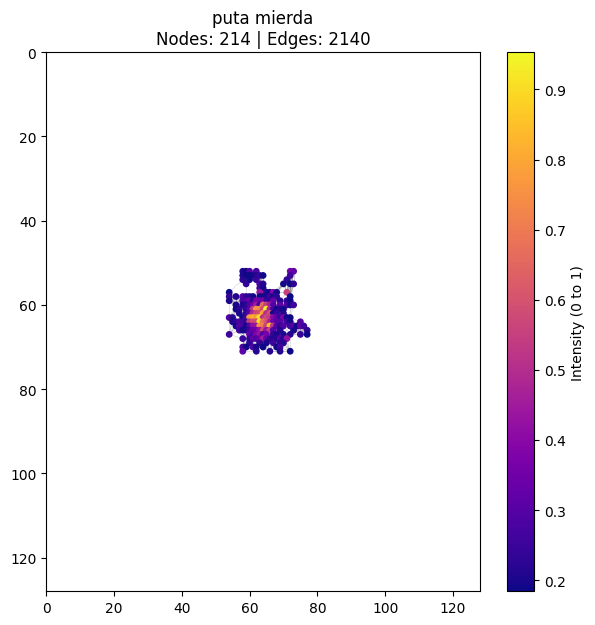

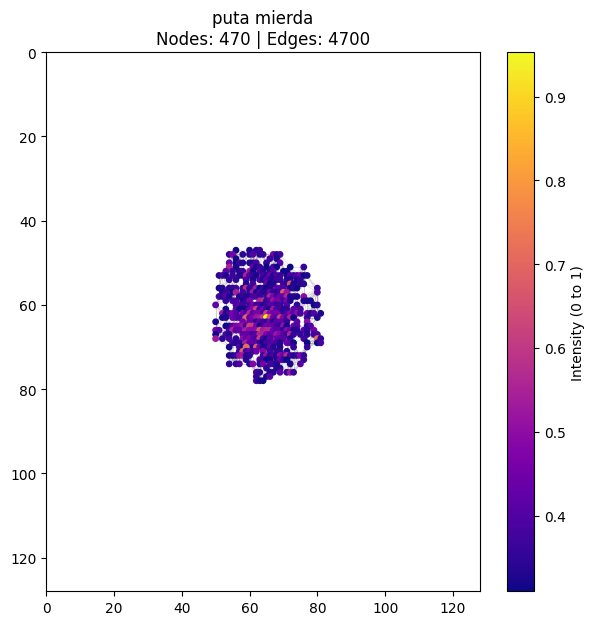

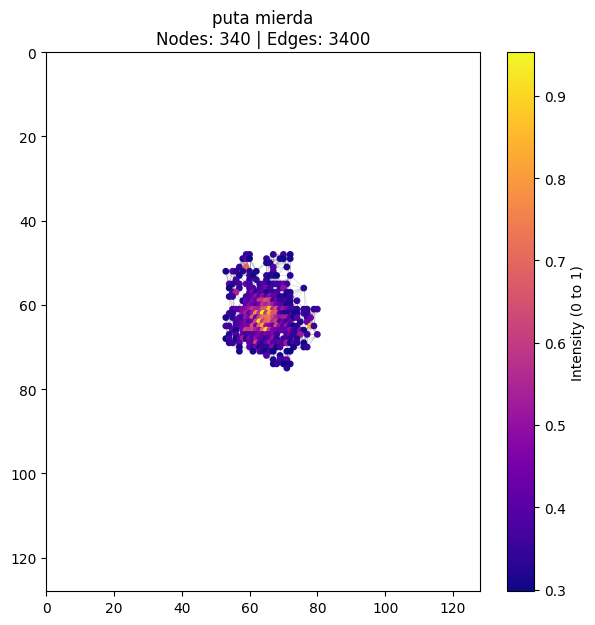

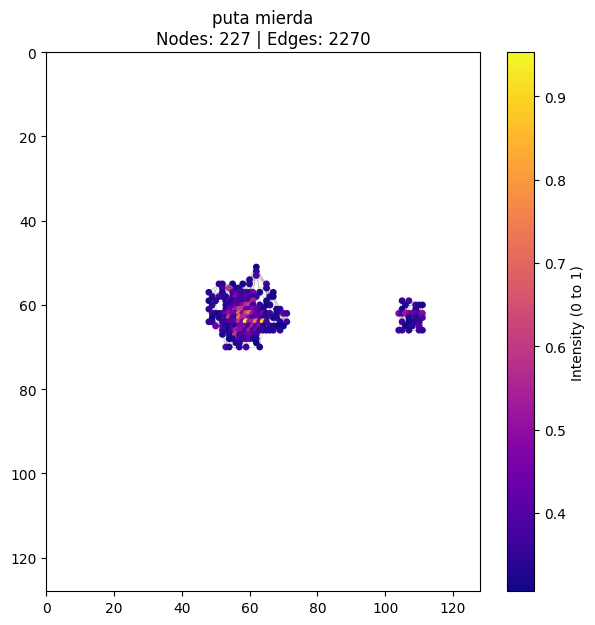

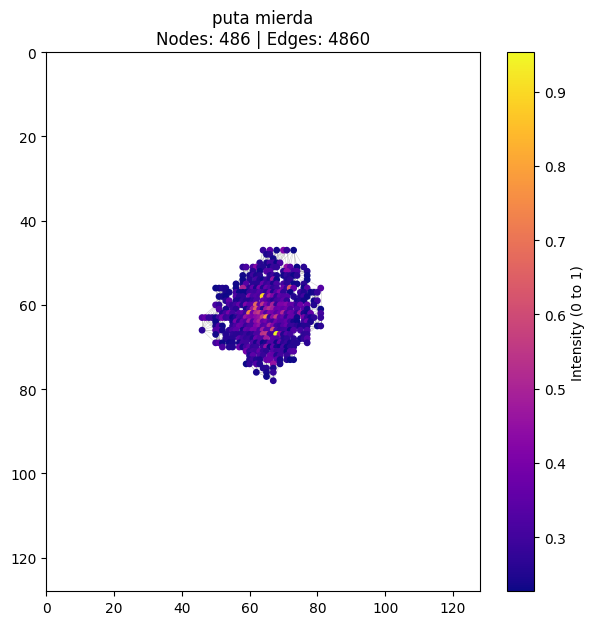

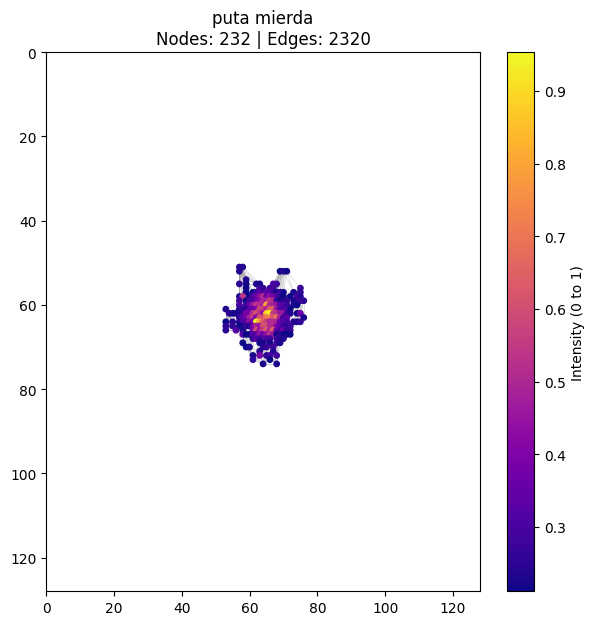

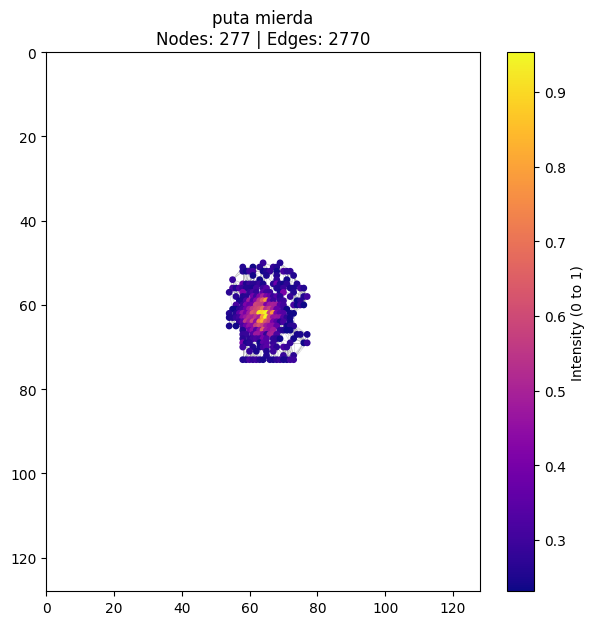

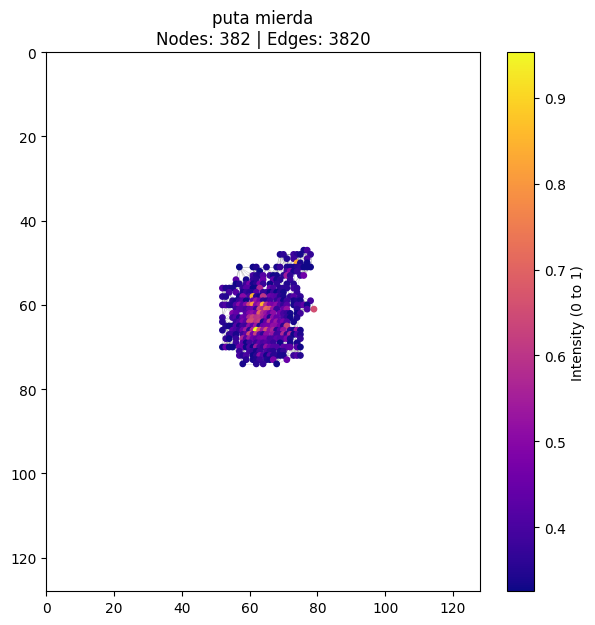

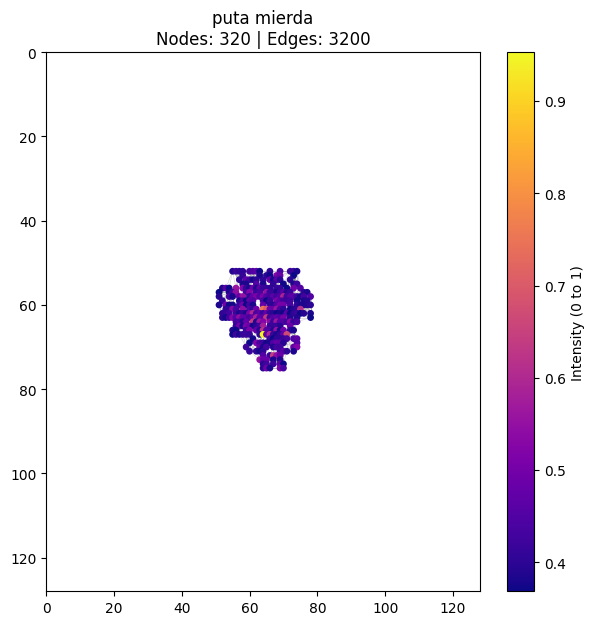

In [85]:
import matplotlib.pyplot as plt

def visualize_extracted_graph(graph_dict, title="Extracted Graph Validation"):
    """
    Plots the extracted nodes and edges using absolute pixel coordinates.
    """
    if graph_dict is None or 'X' not in graph_dict:
        print("No graph data to visualize.")
        return
        
    nodes = graph_dict['X'].numpy()
    edges = graph_dict['A'].numpy()
    
    # Column 0 is X, Column 1 is Y, Column 2 is Intensity
    x_coords = nodes[:, 0]
    y_coords = nodes[:, 1] 
    intensities = nodes[:, 2]

    plt.figure(figsize=(7, 7))
    
    # 1. Draw the Edges (Connections)
    for i in range(edges.shape[1]):
        source_idx = edges[0, i]
        target_idx = edges[1, i]
        
        plt.plot(
            [x_coords[source_idx], x_coords[target_idx]],
            [y_coords[source_idx], y_coords[target_idx]],
            color='gray', alpha=0.3, linewidth=0.5, zorder=1
        )
        
    # 2. Draw the Nodes (Colored by pixel intensity)
    scatter = plt.scatter(
        x_coords, y_coords, 
        c=intensities, cmap='plasma', s=15, zorder=2
    )
    
    plt.colorbar(scatter, label="Intensity (0 to 1)")
    plt.title(f"{title}\nNodes: {len(x_coords)} | Edges: {edges.shape[1]}")
    
    # Set limits to your image size (128x128)
    plt.xlim(0, 128)
    plt.ylim(0, 128)
    
    # Invert the Y-axis! Image matrices start with Y=0 at the TOP. 
    # Standard plots put Y=0 at the bottom. We invert to match the original image view.
    plt.gca().invert_yaxis()
    
    plt.axis('on') # Kept 'on' so you can see the 0-128 coordinate boundaries
    plt.show()

# --- Test it on the very first image in your processed list! ---
for i in range (0,9):
    visualize_extracted_graph(std_graphs[2*i], title="puta mierda")


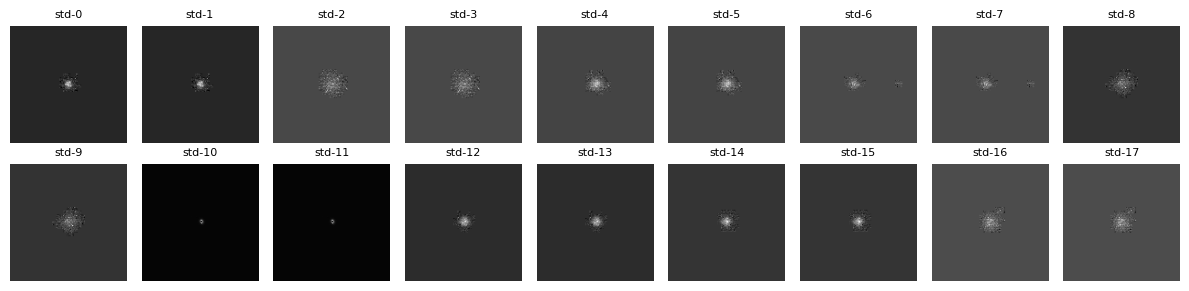

In [86]:
visualize_grid(std_images[0:18], titles=[f"std-{i}" for i in range(18)], ncol=9)